In [86]:
import pandas as pd 
from matplotlib import pyplot as plt
from matplotlib import gridspec as gridspec
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D
from pathlib import Path
import numpy as np

plt.style.use('seaborn-darkgrid')

## spike calling method
# use percentage based threshold of the data distribution instead of a global/local method, if on global/local will not be used! --- default: False
percentage_based_threshold = False
# percentage of data distribution for simple method --- default: 0.99 (min 0.00 & max 1.00)
percentage_threshold = 0.95
# global standard deviation (stddev) based on data, threshold can be set to n times the stddev --- default: 3 (recommended: multiplier not lower than 2.5, but needs optimalisation)
global_standard_deviation_threshold_multiplier = 3
# under noise standard deviation based on data and global stddev multiplier, threshold can be set to n times the stddev --- default: 5 (needs optimalisation)
under_noise_standard_deviation_threshold_multiplier = 5

## spike calling settings
# how many seconds to wait after a spike peak has been to defined before another spike can start to be defined --- default: 3 (needs optimalisation)
spike_offset_time = 3
# time offset in seconds to detect overlap in spikes from other video (as measurements are not on the exact same time scale) --- default: 0.2 (needs optimalisation)
nb_time_offset = 5

## network burst detection settings
# perecentage of how many traces are required to contribute to a Network Burst (NB) to have it count for plotting and statistics --- default: 0.3 (30%, depends on data, n_traces per group) 
n_traces_for_NB_per_group_threshold = 0.3

## plotting settings
# plot rectangles on traces to show network_bursts --- default: True (TODO use this parameter in function call)
to_define_network_bursts = True
# plot rectangles on traces to show which spikes were > stddev_threshold --- default: False (TODO use this parameter in function call)
to_define_spikes = False
# quality control plot, used to check if using stddev_threshold made sense --- default: False (TODO use this parameter in function call)
to_plot_distributions = False
# plot equal trace lengths for neatness or false to show each individual trace length --- default: False (TODO use this parameter in function call)
show_equal_trace_length = False

In [87]:
data = Path('data/adjusted for doubles').glob('*.xlsx')
dataframes = []

for xlsx in data:
    df = pd.read_excel(xlsx, index_col = 0, engine = 'openpyxl')
    # renaming df index for clarity and brevity 
    index = []
    raw_smooth = 'smooth'
    for name in df.index.values.tolist():
        if 'raw' in name:
            raw_smooth = 'raw'
        # keep well.video.neuronID
        name = name[7:12]
        index.append('{}.{}'.format(name, raw_smooth))
    df.index = index
    dataframes.append(df)

# merge all dataframes from separate .xlsx files 
df_merged = pd.DataFrame()
for df in dataframes:
    df_merged = df_merged.append(df)
df = df_merged.T

# DEVNOTE: removed all raw columns, for now not working with raw data! 
for name in df.columns:
    if 'raw' in name:
        del df[name]

In [88]:
def check_spikes(df, global_sd_multiplier = 3, under_noise_sd_multiplier = 3, spike_offset = 0.5, percentage_based_threshold = True, percentage = 0.99):
    start = []
    peak = []
    # end = [] # DEPRECATED, peak are new ends 
    index = []
    stats_index = []
    stats_n_spikes = []
    stats_spikes_time = []
    stats_seconds_measured = []
    threshold_data = []
    threshold_indices = []
    for (col, data) in df.iteritems():
        # create numpy data to enable masking
        npdata = np.array(df[col]).astype(np.double)
        # create mask to obtain pure trace data
        mask = np.isfinite(npdata)

        print(1, percentage)

        # use simple percentage based on data distribution method or mediocre sophisticated global/local threshold 
        if percentage_based_threshold:
            sorted_data = data[mask].sort_values()
            threshold_index = int(percentage*len(data[mask]))
            threshold = sorted_data.iloc[threshold_index]
        else:
            # define 'global' standard deviation - global meaning for whole trace data
            global_stddev = np.std(df[col][mask])
            # define noise threshold
            noise_threshold = global_stddev * global_sd_multiplier
            # data under noise threshold, used to calculate under noise stddev
            under_noise_threshold = data[mask] < noise_threshold
            # define under noise data stddev from all data under noise threshold
            under_noise_stddev = np.std(data[mask][under_noise_threshold])
            # define threshold 
            threshold = under_noise_stddev * under_noise_sd_multiplier

        # save threshold for plotting
        threshold_data.append(threshold)
        # trace name
        threshold_indices.append(col)

        # add a starting point when start_possible and peak_possible and value > threshold
        # add peak when trace starting to decreaes, peak_possible and not start_possible 
        # reset peak_possible and start_possible to true when enough time passed (spike_offset) after peak detected 
        count = 0
        old_value = 0
        peak_value = 0 
        peak_index = 0
        peak_possible = True
        start_possible = True
        for (idx, value) in data[mask].iteritems():
            increasing = value > old_value
            if value > threshold:
                # print(idx, value, peak_index - idx)
                
                if increasing == True and peak_possible == True: 
                    peak_value = value 
                    peak_index = idx
                    if start_possible == True:
                        # print('first over threshold')
                        start.append(idx)
                        start_possible = False
            if increasing == False and peak_possible == True and start_possible == False:
                # print('peak found')
                # peak found, add as spike 
                peak_possible = False
                peak.append(peak_index)
                index.append(col)
                count += 1
            if increasing == False and (idx - peak_index) > spike_offset and start_possible == False and peak_possible == False:
                # print('reset for time')
                peak_possible = True
                start_possible = True
            if value < threshold and (idx - peak_index) > spike_offset and start_possible == False and peak_possible == False:
                # print('reset for threshold')
                peak_possible = True
                start_possible = True
            # set to check if trace increasing or decreasing  
            old_value = value

        # extract stats - where idx = total measure time per video
        stats_index.append(col)
        stats_n_spikes.append(count)
        stats_spikes_time.append((count/idx) * 60)
        stats_seconds_measured.append(idx)
        
        # # sometimes a spike did not recover ('end') as measuring was cut off, append closing time to ends
        if len(start) > len(peak):
            peak.append(idx)
            index.append(col)

    threshold_data = {'threshold': threshold_data}
    df_threshold = pd.DataFrame(data = threshold_data, index = threshold_indices)

    # initiate stats data to create data frame
    stats_data = {'n_spikes': stats_n_spikes, 'spikes_per_minute': stats_spikes_time, 'seconds_measured': stats_seconds_measured}
    # create spike stats dataframe
    df_stats = pd.DataFrame(data = stats_data, index = stats_index)

    data = {'start': start, 'end': peak}
    df_spikes = pd.DataFrame(data = data, index = index)
    
    return df_spikes, df_stats, df_threshold
            
df_spikes, df_stats_spikes, df_threshold = check_spikes(df, global_sd_multiplier = global_standard_deviation_threshold_multiplier, under_noise_sd_multiplier = under_noise_standard_deviation_threshold_multiplier, spike_offset = spike_offset_time, percentage_based_threshold = percentage_based_threshold, percentage = percentage_threshold)
    

1 0.95
1 0.95
1 0.95
1 0.95
1 0.95
1 0.95
1 0.95
1 0.95
1 0.95
1 0.95
1 0.95
1 0.95
1 0.95
1 0.95
1 0.95
1 0.95
1 0.95
1 0.95
1 0.95
1 0.95
1 0.95
1 0.95
1 0.95
1 0.95
1 0.95


In [137]:
def check_network_bursts(df_spikes, time_offset = 0.2, n_traces_for_NB_per_group_threshold = 0.3):
    df = df_spikes['start']

    # TODO should spike ends be taken in to account for better NB detection? 

    # initiate dictionary with value information per 'group' (well, video, raw_smooth)
    iterdict = {}
    # initiate dictionary with amount of network_bursts
    stats_traces = {}
    stats_groups = {}
    # fill iterdict by grouping values
    for (name, value) in df.iteritems():
        # get keys for dict 
        well = int(name.split('.')[0])
        video = int(name.split('.')[1])
        trace = int(name.split('.')[2])
        raw_smooth = name.split('.')[3]
        # initiate dict grouping with keys/values 
        if not well in iterdict.keys():
            iterdict[well] = {}
        if not video in iterdict[well].keys():
            iterdict[well][video] = {}
        if not raw_smooth in iterdict[well][video].keys():
            iterdict[well][video][raw_smooth] = {}
        if not trace in iterdict[well][video][raw_smooth].keys():
            iterdict[well][video][raw_smooth][trace] = []
        iterdict[well][video][raw_smooth][trace].append(value)

        # initiate stats dicts with 0 network bursts for each trace and group 
        if name not in stats_traces.keys():
            stats_traces[name] = 0
            stats_groups['{}.{}'.format(well, video)] = 0
        
    def evaluate_statistics(hits, n_traces_in_group):
        print("NEW GROUP")
        # sort hits
        hits['start'], hits['name'] = (list(l) for l in zip(*sorted(zip(hits['start'], hits['name']))))

        # initiate remaining hits that will be returned for plotting
        remaining_hits = {'name': [], 'start': []}
        # initiate with first name and start_time 
        old_name = hits['name'][0]
        old_start = hits['start'][0]
        # save names temporarily while counting to go over percentage threshold reached for minimal amount of traces contributing to network burst 
        temp_names = []


        # TODO check prints, first of new group seems to be skipped but gets added in print 3 as initiate of temp_names = [name]
        ## values and traces obviously missing, like 1.1.2
        ## also check 3 1.1.4.smooth 65.92845
                    # 1 1.1.5.smooth 65.92845
                    # 3 1.1.1.smooth 66.183
                    # 2 1.1.3.smooth 66.183    time difference is allowed but doesn't make sense based on plot, check when spike defined if this makes sense? 
        for name, start in zip(hits['name'], hits['start']):
            if name == old_name and start > old_start - time_offset and start < old_start + time_offset:
                print(1, name, start)
                pass
            elif start > old_start - time_offset and start < old_start + time_offset:
                print(2, name, start)
                temp_names.append(name)
            else:
                print(3, name, start)
                # process old group
                if len(temp_names)/n_traces_in_group > n_traces_for_NB_per_group_threshold:
                    for name in temp_names:
                        stats_traces[name] += 1
                        remaining_hits['name'].append(name)
                        remaining_hits['start'].append(start)
                    well = int(name.split('.')[0])
                    video = int(name.split('.')[1])
                    stats_groups['{}.{}'.format(well, video)] += 1
                # initiate new group
                temp_names = [name]
            old_name = name
            old_start = start 
        
        # process final group
        if len(temp_names) > 1 and len(temp_names)/n_traces_in_group > n_traces_for_NB_per_group_threshold:
            for name in temp_names:
                stats_traces[name] += 1
                remaining_hits['name'].append(name)
                remaining_hits['start'].append(start)
            well = int(name.split('.')[0])
            video = int(name.split('.')[1])
            stats_groups['{}.{}'.format(well, video)] += 1
        return remaining_hits




    # TODO check remaining summary statistics errors where <1 for #spikes and #NBs theoretically not possible 
    ## go over with prints per trace in group that goes <1 


    # TODO spike_ends for NB detection
    # TODO n_spikes < n_bursts for 1 trace impossible 

    # initiate hits dict (network burst per group per trace are added in here for extraction --> plotting)
    all_hits = {'name': [], 'start': []}
    group_hits = {'name': [], 'start': []}
    # need dict per value_hits to see if x.x.1 does not get added in double
    value_hits = {'name': [], 'start': []}
    old_video_num = 1
    old_val1 = 0
    
    # loop iterdict to compare all 'grouped' (well, video, raw_smooth) traces for overlap (network bursts) in values
    for well in iterdict.keys():
        for video in iterdict[well].keys():
            # if next group found evaluate and add to all_hits for plotting
            if video != old_video_num:
                group_hits = evaluate_statistics(group_hits, n_traces_in_group)
                all_hits['name'] += group_hits['name']
                all_hits['start'] += group_hits['start']
            # reset for new group
            old_video_num = video
            group_hits = {'name': [], 'start': []}
            for r_s in iterdict[well][video].keys():
                # get total amount of traces in group (and type)
                n_traces_in_group = len(iterdict[well][video][r_s].keys())
                for trace in iterdict[well][video][r_s].keys():
                    # remove trace itself from other traces to compare values of itself onto only the other for network bursts 
                    other_traces = list(iterdict[well][video][r_s].keys())
                    other_traces.remove(trace) 
                    for val1 in iterdict[well][video][r_s][trace]:
                        # if next value found add all checked value hits to the group_hits
                        if old_val1 != val1:
                            group_hits['name'] += value_hits['name']
                            group_hits['start'] += value_hits['start'] 
                        # reset for new value 
                        old_val1 = val1
                        value_hits = {'name': [], 'start': []}
                        for trace2 in other_traces:
                            for val2 in iterdict[well][video][r_s][trace2]:
                                # check only if trace < trace2 (no need for double+ network_burst entries)
                                # check if value from trace 1 in range around value of trace 2 (start time time_offset)
                                # TODO this is where to implement spike_ends
                                if trace2 > trace and val1 > val2 - time_offset and val1 < val2 + time_offset:
                                    name1 = '{}.{}.{}.{}'.format(well, video, trace, r_s)
                                    name2 = '{}.{}.{}.{}'.format(well, video, trace2, r_s)
                                    add1, add2 = True, True
                                    # get indices where val1 in group_hits['start]
                                    indices = [i for i, x in enumerate(group_hits['start']) if x == val1]
                                    # check if combination of (name, start) already in group_hits, if so, flag to false to do not add to value_hits 
                                    for i in indices:
                                        if group_hits['name'][i] == name1:
                                            add1 = False
                                        if group_hits['name'][i] == name2:
                                            add2 = False
                                    if add1: # TODO deprecated, check if works well now:   and value_hits['name'] == []
                                        value_hits['name'].append(name1)
                                        value_hits['start'].append(val1)
                                    if add2: 
                                        value_hits['name'].append(name2)
                                        value_hits['start'].append(val2)
                                    # don't check other values of same trace2 if match found, go to next trace (speeds up code)
                                    break

    # final group evaluation if hits found
    if group_hits['name'] != []:
        group_hits = evaluate_statistics(group_hits, n_traces_in_group)
        all_hits['name'] += group_hits['name']
        all_hits['start'] += group_hits['start'] 

    # create NB stats dataframe 
    df_stats_network_bursts = pd.DataFrame(data = list(stats_traces.values()), index = list(stats_traces.keys()), columns = ['n_network_bursts'])
    # add amount of network bursts per group to NB stats
    n_network_bursts_group = []
    for name in df_stats_network_bursts.index:
        well = int(name.split('.')[0])
        video = int(name.split('.')[1])
        index = '{}.{}'.format(well, video)
        n_network_bursts_group.append(stats_groups[index])
    df_stats_network_bursts['n_network_bursts_group'] = n_network_bursts_group

    # create hits dataframe for plotting
    df_hits = pd.DataFrame(data = all_hits['start'], index = all_hits['name'], columns = ['start'])
    
    return df_hits, df_stats_network_bursts

df_network_bursts, df_stats_network_bursts = check_network_bursts(df_spikes, time_offset = nb_time_offset, n_traces_for_NB_per_group_threshold = n_traces_for_NB_per_group_threshold)

NEW GROUP
1 1.1.3.smooth 36.90975
1 1.1.3.smooth 36.90975
2 1.1.4.smooth 36.90975
2 1.1.5.smooth 36.90975
3 1.1.4.smooth 65.92845
1 1.1.5.smooth 65.92845
3 1.1.1.smooth 66.183
2 1.1.3.smooth 66.183
3 1.1.1.smooth 93.92895
2 1.1.4.smooth 93.92895
3 1.1.3.smooth 126.7659
2 1.1.5.smooth 126.7659
3 1.1.1.smooth 169.0212
2 1.1.1.smooth 169.0212
2 1.1.3.smooth 169.0212
2 1.1.4.smooth 169.0212
3 1.1.3.smooth 197.27625
2 1.1.5.smooth 197.27625
3 1.1.1.smooth 197.5308
2 1.1.4.smooth 197.5308
3 1.1.1.smooth 241.56795
2 1.1.1.smooth 241.56795
2 1.1.3.smooth 241.56795
2 1.1.5.smooth 241.56795
3 1.1.1.smooth 285.35055
2 1.1.1.smooth 285.35055
2 1.1.3.smooth 285.35055
2 1.1.4.smooth 285.35055
3 1.1.3.smooth 317.6784
2 1.1.5.smooth 317.6784
3 1.1.1.smooth 367.0611
2 1.1.4.smooth 367.0611
3 1.1.1.smooth 416.69835
2 1.1.3.smooth 416.69835
3 1.1.1.smooth 441.8988
2 1.1.1.smooth 441.8988
2 1.1.3.smooth 441.8988
2 1.1.5.smooth 441.8988
3 1.1.2.smooth 532.0095
2 1.1.2.smooth 532.0095
2 1.1.3.smooth 532.009

In [138]:
def plot_distribution(df, type, well):
    custom_colors = [(0,0,0), (146,0,0), (73,0,146), (219,109,0), (0,109,219), (182,109,255), (182,219,255), (146,0,0), (109,182,255), 
                         (36,255,36), (255,182,219), (0,73,73), (255,255,109), (146,73,0), (255,109,182), (58,58,0), (0,146,146)]

    # calculate how many traces within condition (correct well and type)
    nrows = 0
    for col in df.columns:
        if well == int(col.split('.')[0]) and type == col.split('.')[3]:
            nrows += 1

    # instantiate plot 
    fig, axes = plt.subplots(nrows = nrows, ncols = 1, sharex=True, figsize=(25, 20))
    plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=None, hspace=0.05)
    plt.suptitle('Distribution - All videos, well: {}, type: {}'.format(well, type), fontsize=24)
    # xlabel
    fig.text(0.5, 0.04, 'Timepoints (s)', ha='center', fontsize=24)
    # ylabel
    fig.text(0.04, 0.5, 'Occurence (%)', va='center', rotation='vertical', fontsize=24)

    nrow = 0
    for col in df.columns:
        if well == int(col.split('.')[0]) and type == col.split('.')[3]:
            # get color from color blind friendly color list (custom)
            color = list(map(lambda x: x/255, custom_colors[int(col.split('.')[1])]))
            
            # get xdata 
            xdata = np.array(df[col]).astype(np.double)
            xmask = np.isfinite(xdata)

            # plot data 
            axes[nrow].hist(xdata[xmask], bins = 10, label = col, color=color)
            
            # bump index for plotting in correct matplotlib plot figure axes
            nrow += 1

    # add legend
    fig.legend(prop={'size': 20})
    # save plot
    fig.savefig('plots/Distribution-Well_{}-Type_{}'.format(well, type))


In [139]:
## DEPRECATED PLOT TRACES

# DEVNOTE: keep for understanding if something does go wrong in new plot_traces

# def plot_traces(df, type, well, spikes, network_bursts, thresholds, define_spikes = False, define_network_bursts = True, show_equal_trace_length = True):
#     custom_colors = [(0,0,0), (146,0,0), (73,0,146), (219,109,0), (0,109,219), (182,109,255), (182,219,255), (146,0,0), (109,182,255), 
#                          (36,255,36), (255,182,219), (0,73,73), (255,255,109), (146,73,0), (255,109,182), (58,58,0), (0,146,146)]
    
#     # no overlap in defining network_bursts and spikes on user input accident 
#     if define_network_bursts:
#         define_spikes = False

#     # calculate how many traces within condition (correct well and type)
#     nrows = 0
#     last_valid_trace_indices = []
#     for col in df.columns:
#         if well == int(col.split('.')[0]) and type == col.split('.')[3]:
#             nrows += 1
#             # from col grab last value, check with index at what final time that is, plot all traces to minimal final time 
#             last_valid_trace_indices.append(df[col].last_valid_index())
#     minimal_last_trace_index = min(last_valid_trace_indices)

#     # instantiate plot 
#     fig, axes = plt.subplots(nrows = nrows, ncols = 1, sharex=True, figsize=(25, 20))
#     plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=None, hspace=0.05)
#     plt.suptitle('All videos, well: {}, type: {}'.format(well, type), fontsize=24)
#     # xlabel
#     fig.text(0.5, 0.04, 'Time (s)', ha='center', fontsize=24)
#     # ylabel
#     ylabel = u'Calcium trace (ΔF/F)' if 'raw' in type else u'Inferred calcium trace (ΔF/F)'
#     fig.text(0.04, 0.5, ylabel, va='center', rotation='vertical', fontsize=24)
    
#     # get minimally shared x-axis data
#     xdata = np.array(df.index).astype(np.double)
    
#     nrow = 0
#     for col in df.columns:
#         if well == int(col.split('.')[0]) and type == col.split('.')[3]:
#             # get color from color blind friendly color list (custom)
#             color = list(map(lambda x: x/255, custom_colors[int(col.split('.')[1])]))
#             # get fluorescence spiking data
#             ydata = np.array(df[col]).astype(np.double)
#             # get mask to filter None/nan data (to plot continuous lines)
#             ymask = np.isfinite(ydata)
            
#             # plot data in correct matplotlib plot figure axes
#             axes[nrow].plot(xdata[ymask], ydata[ymask], linestyle='-', marker='', label = col, color=color, alpha = .9)
            
#             # TODO plot horizontal line to show used standard deviation for the trace
#             # print(1, )
#             axes[nrow].axhline(y=thresholds['threshold'][col], xmin=0.00, xmax=1, color='black', linestyle='dotted', alpha = 0.6)

#             # network bursts: define with lighter colored retangles
#             if define_network_bursts:
#                 for (ind, start) in zip(network_bursts.index, network_bursts.start):
#                     if col == ind:
#                         axes[nrow].add_patch(Rectangle(xy = (start, 0), width = 2, height = max(ydata[ymask]), facecolor=color, alpha=.9))

#             # spikes: define with lighter colored retangles
#             if define_spikes:
#                 for (ind, start, end) in zip(spikes.index, spikes.start, spikes.end):
#                     if col == ind:
#                         axes[nrow].add_patch(Rectangle(xy = (start, 0), width = end-start + 1, height = max(ydata[ymask]), facecolor=color, alpha=0.3))

#             # set y-axes ticks every 25% of data (max/4)
#             axes[nrow].set_yticks(np.arange(0, max(ydata[ymask]), round(max(ydata[ymask]) / 2, -1)))
            
#             if show_equal_trace_length:
#                 # set x-axes limit to minimal_last_trace_index for neat visualization (all traces show equal length of time)
#                 axes[nrow].set_xlim([0, minimal_last_trace_index])

#             # bump index for plotting in correct matplotlib plot figure axes
#             nrow += 1

#     # add threshold to legend (Artist class)
#     threshold_artist = plt.Line2D((0,1),(0,0), color='k', linestyle = 'dotted')
#     # get needed lines/handlers and labels from created axes and modify for grouped legend
#     lines = []
#     labels = []
#     new_group = 1
#     for ax in fig.axes:
#         Line, Label = ax.get_legend_handles_labels()
#         if int(Label[0].split(".")[1]) == new_group:
#             lines.extend(Line)
#             labels.extend(["Group " + str(new_group)])
#             new_group += 1
#     # add legend
#     fig.legend([handle for i,handle in enumerate(lines)]+[threshold_artist], [label for i,label in enumerate(labels)]+['Threshold'], prop={'size': 20})

#     # save plot
#     fig.savefig('plots/Well_{}-Type_{}'.format(well, type))

In [140]:
def plot_traces(df, type, well, spikes, network_bursts, thresholds, define_spikes = False, define_network_bursts = True, show_equal_trace_length = True):
    custom_colors = [(0,0,0), (146,0,0), (73,0,146), (219,109,0), (0,109,219), (182,109,255), (182,219,255), (146,0,0), (109,182,255), 
                         (36,255,36), (255,182,219), (0,73,73), (255,255,109), (146,73,0), (255,109,182), (58,58,0), (0,146,146)]

    plot_type = 'spikes'
    # no overlap in defining network_bursts and spikes on user input accident 
    if define_network_bursts:
        define_spikes = False
        plot_type = 'NBs'

    # calculate how many traces within condition (correct well and type)
    nrows = 0
    last_valid_trace_indices = []
    for col in df.columns:
        if well == int(col.split('.')[0]) and type == col.split('.')[3]:
            nrows += 1
            # from col grab last value, check with index at what final time that is, plot all traces to minimal final time 
            last_valid_trace_indices.append(df[col].last_valid_index())
    minimal_last_trace_index = min(last_valid_trace_indices)

    # for specific well, get amount of groups based on final trace of well 
    group_trace = {}
    group_trace_data = {}
    for col in df.columns:
        wel = int(col.split('.')[0])
        if well == wel:
            group = int(col.split('.')[1])
            trace = int(col.split('.')[2])
            group_trace[group] = trace
            group_trace_data[str(group) + str(trace)] = df[col]

    n_groups = group

    # inititate plot
    fig = plt.figure(figsize=((25, 20)))
    # initiate grid for amount of groups to subplot iteratively 
    outer = gridspec.GridSpec(n_groups, 1, wspace=0.2, hspace=0.2)
    # plot title
    plt.suptitle('All videos, well: {}, type: {}'.format(well, type), fontsize=24)
    # xlabel
    fig.text(0.5, 0.04, 'Time (s)', ha='center', fontsize=24)
    # ylabel
    ylabel = u'Calcium trace (ΔF/F)' if 'raw' in type else u'Inferred calcium trace (ΔF/F)'
    fig.text(0.04, 0.5, ylabel, va='center', rotation='vertical', fontsize=24)

    # get minimally shared x-axis data
    xdata = np.array(df.index).astype(np.double)

    legend_lines = []
    legend_names = []
    # initialize plot grid layout
    for i in range(n_groups):
        # initiate inner grid (traces) in outer grid (groups) 
        inner = gridspec.GridSpecFromSubplotSpec(group_trace[i+1], 1,
                    subplot_spec=outer[i], wspace=0.1, hspace=0.1)
        # get color from color blind friendly color list (custom)
        color = list(map(lambda x: x/255, custom_colors[i+1]))

        legend_lines.append(Line2D([0], [0], color=color, lw=4))
        legend_names.append("Group " + str(i+1))
        for j in range(group_trace[i+1]):

            try:
                # create dataframe column identifier 
                tuple = (str(well), str(i+1), str(j+1), type)
                col = '.'.join(tuple)

                # get fluorescence spiking data
                ydata = np.array(group_trace_data[str(i+1)+str(j+1)]).astype(np.double)
                # get mask to filter None/nan data (to plot continuous lines)
                ymask = np.isfinite(ydata)
                # initiate axis in inner grid
                ax = plt.Subplot(fig, inner[j])
                fig.add_subplot(ax)

                # remove x-axis ticks when not last trace of group for visibility
                if j+1 != group_trace[i+1]:
                    ax.set_xticks([])
                # plot data
                ax.plot(xdata[ymask], ydata[ymask], linestyle='-', marker='', color=color, alpha = .9)
                # plot used spike threshold
                ax.axhline(y=thresholds['threshold'][col], xmin=0.00, xmax=1, color='black', linestyle='dotted', alpha = 0.6)

                # network bursts: define with lighter colored retangles
                if define_network_bursts:
                    for (ind, start) in zip(network_bursts.index, network_bursts.start):
                        if col == ind:
                            ax.add_patch(Rectangle(xy = (start, 0), width = 2, height = max(ydata[ymask]), facecolor=color, alpha=.9))

                # spikes: define with lighter colored retangles
                if define_spikes:
                    for (ind, start, end) in zip(spikes.index, spikes.start, spikes.end):
                        if col == ind:
                            ax.add_patch(Rectangle(xy = (start, 0), width = end-start + 1, height = max(ydata[ymask]), facecolor=color, alpha=0.3))

                # set y-axes ticks every 25% of data (max/4)
                ax.set_yticks(np.arange(0, max(ydata[ymask]), round(max(ydata[ymask]) / 2, -1)))
                
                if show_equal_trace_length:
                    # set x-axes limit to minimal_last_trace_index for neat visualization (all traces show equal length of time)
                    ax.set_xlim([0, minimal_last_trace_index])

            except KeyError:
                pass

    # add threshold to legend (Artist class)
    threshold_artist = plt.Line2D((0,1),(0,0), color='k', linestyle = 'dotted')
    legend_lines.append(threshold_artist)
    legend_names.append("Threshold")
    fig.legend(legend_lines, legend_names, prop={'size': 20})

    # save plot
    fig.savefig('plots/Well_{}-Type_{}-PlotType_{}'.format(well, type, plot_type))


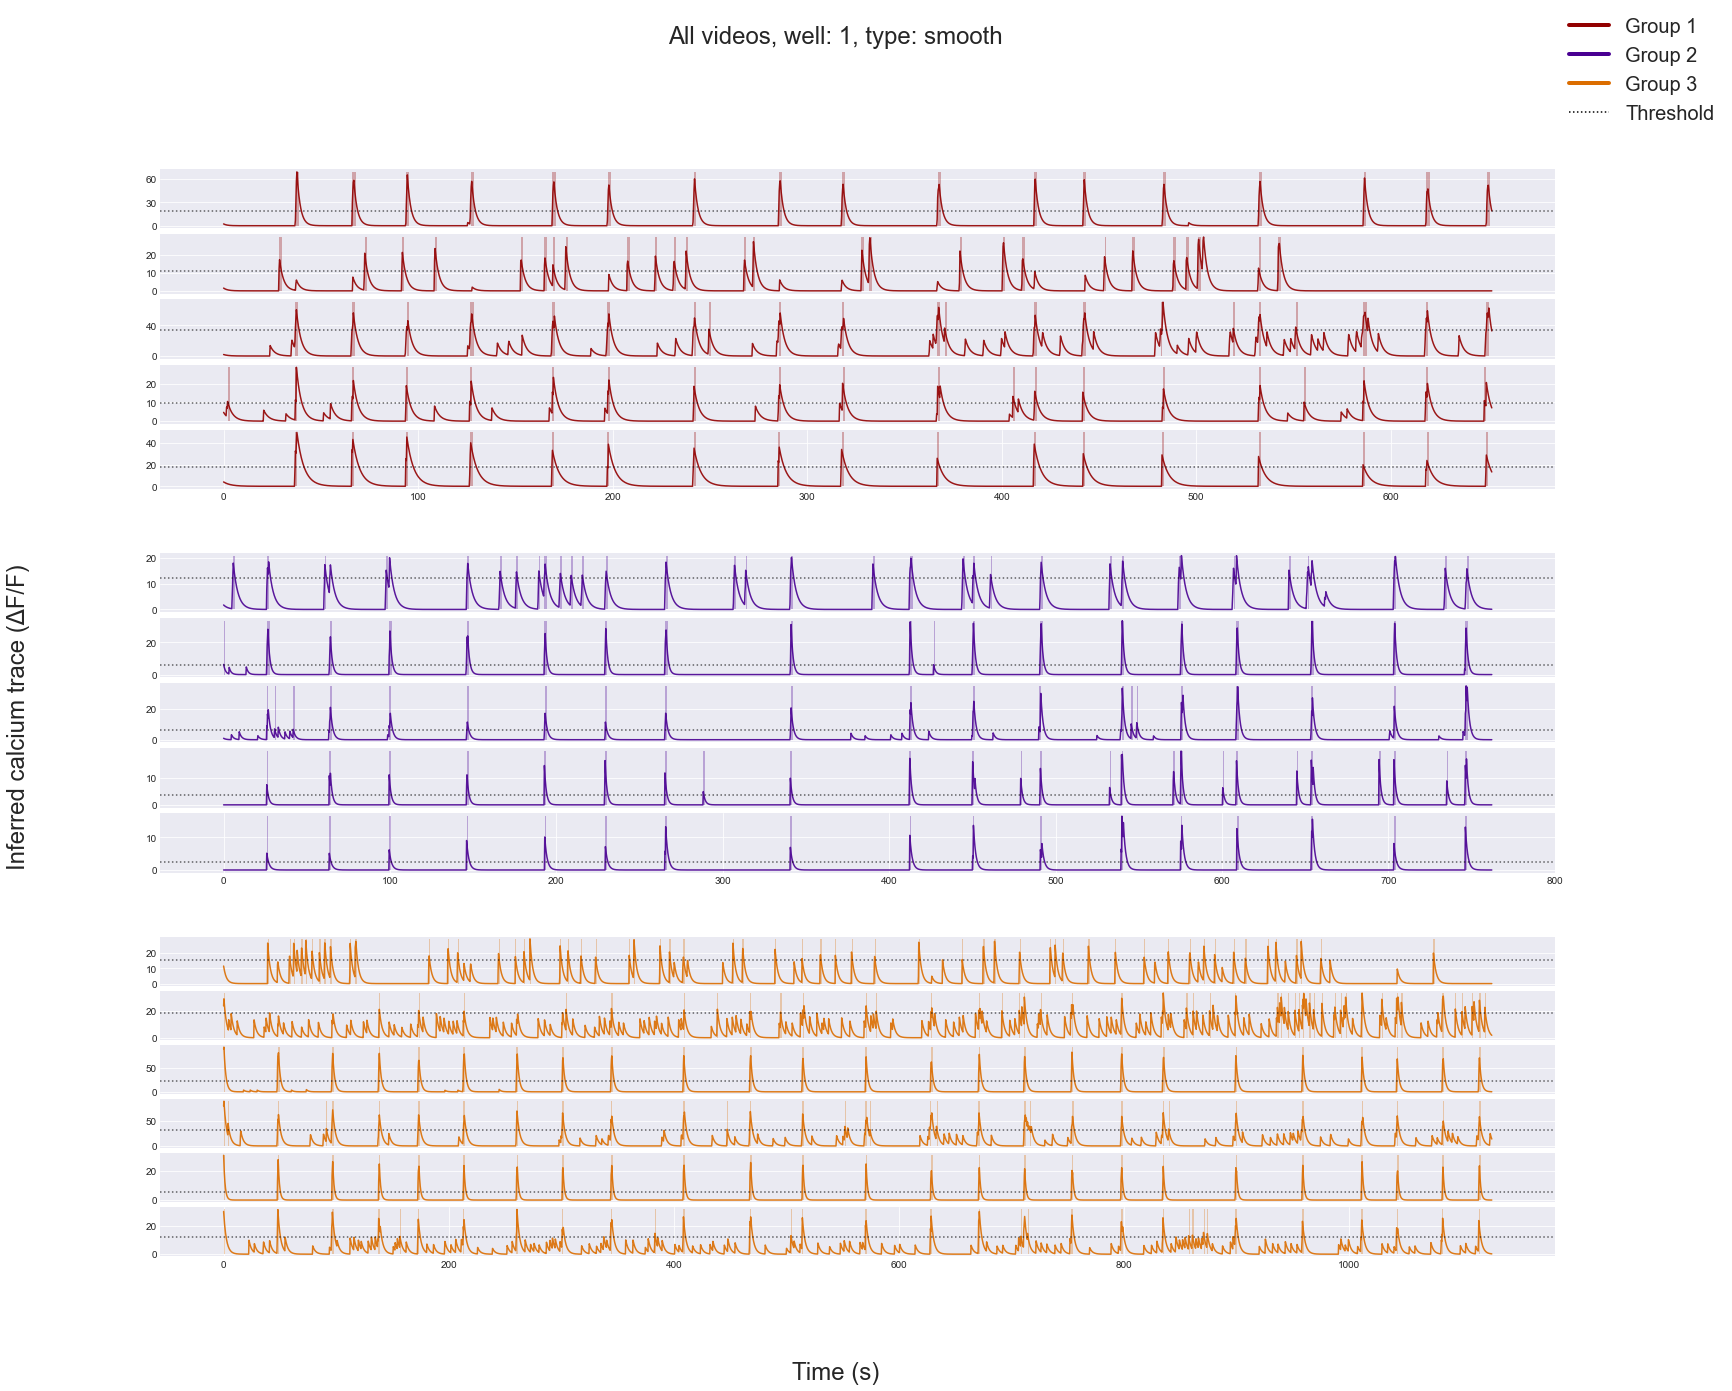

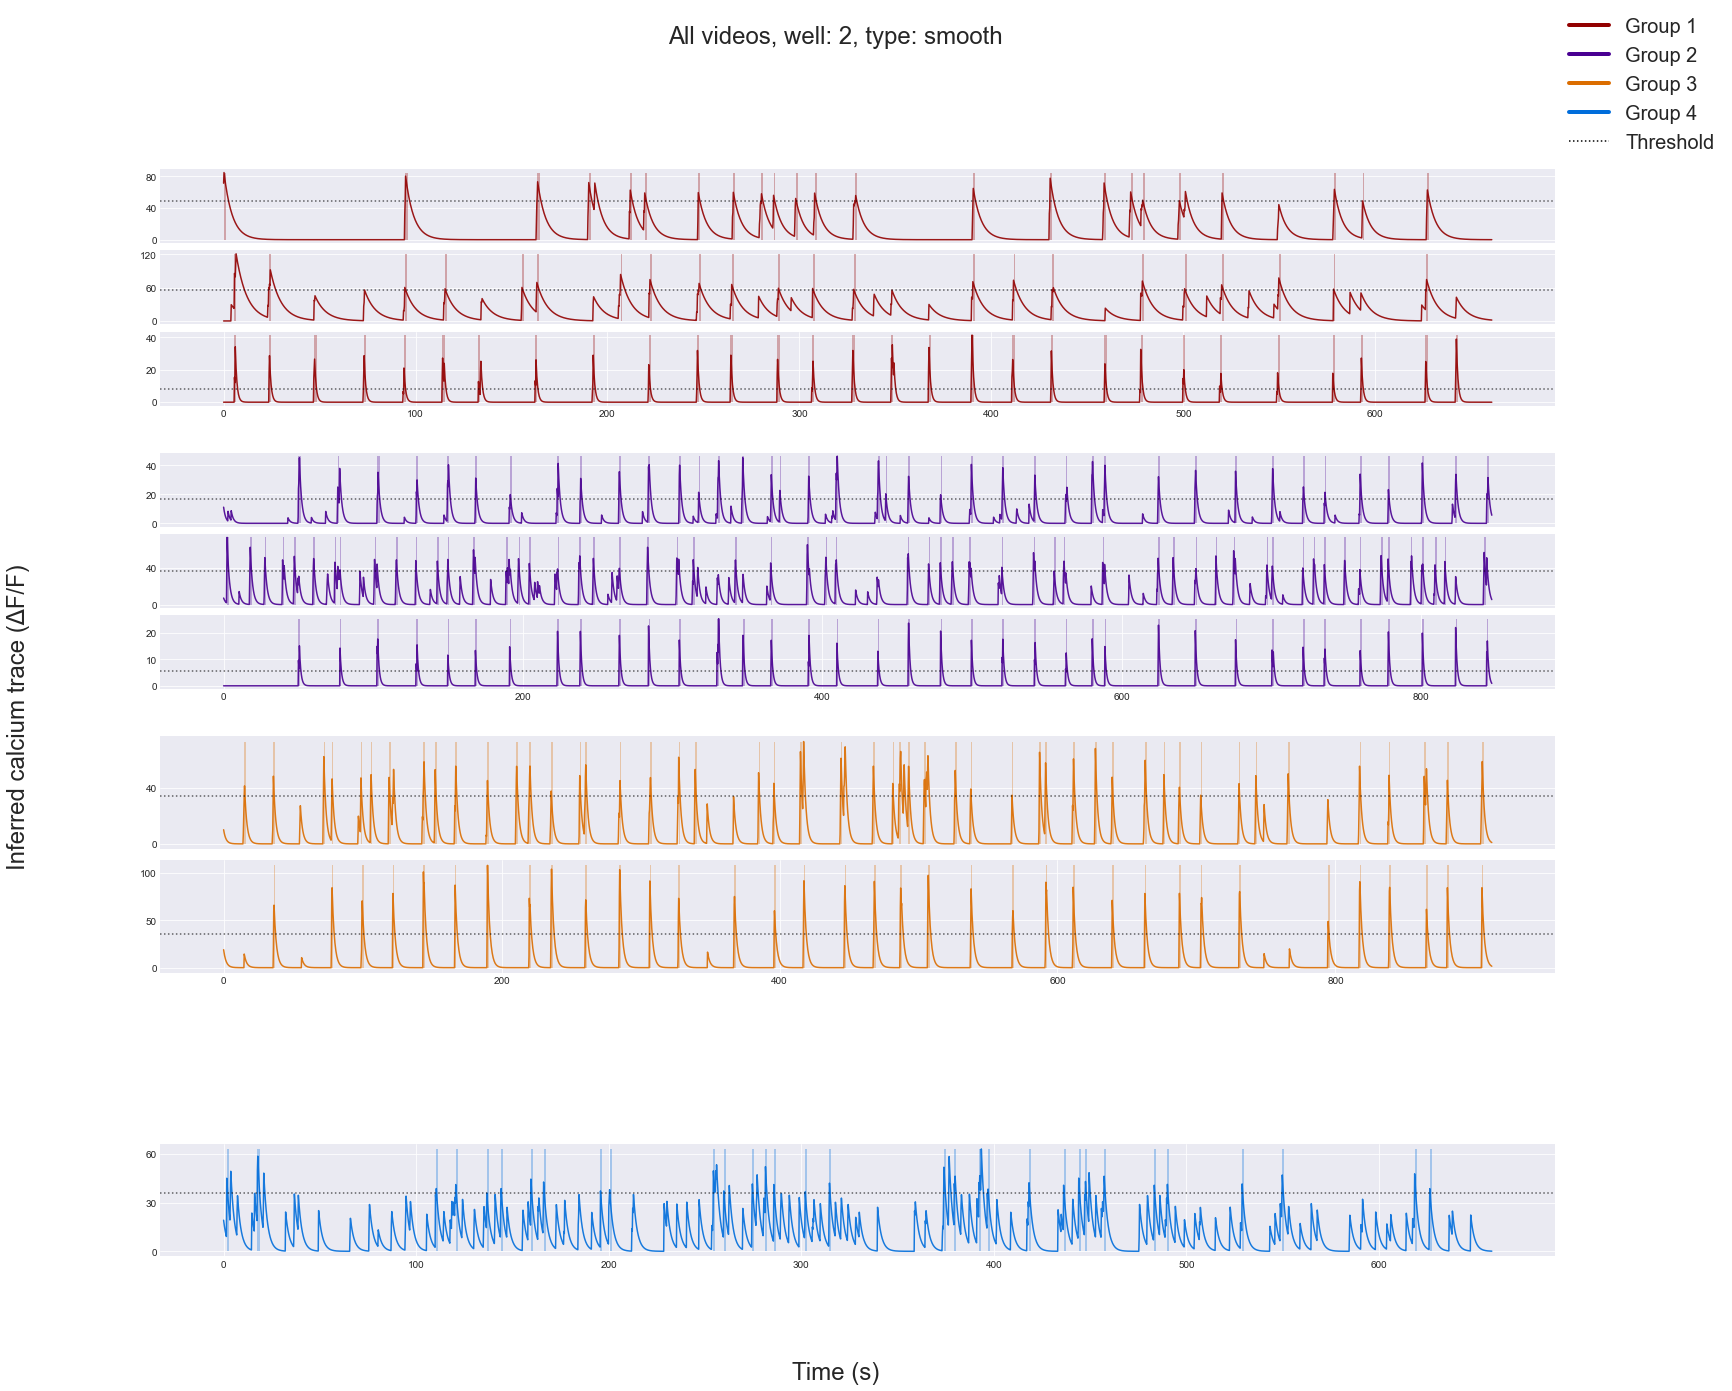

In [141]:
# df with traces/neurons as columns 

# take final column (trace) and extract it's well to get total amount of wells 
n_wells = int(df.columns[-1].split('.')[0])
data_types = ['smooth'] # DEVNOTE: for now removed 'raw'
# create separate figures for wells and raw/smooth data types 
for n in range(1, n_wells + 1):
    for type in data_types:
        # TODO reinput defaults: define_spikes = to_define_spikes, define_network_bursts = to_define_network_bursts
        plot_traces(df = df, type = type, well = n, spikes = df_spikes, network_bursts = df_network_bursts, thresholds = df_threshold, define_spikes = True, define_network_bursts = False,                         show_equal_trace_length = show_equal_trace_length)
        if to_plot_distributions:
            plot_distribution(df = df, type = type, well = n)


In [142]:
pd_stats = pd.concat([df_stats_spikes, df_stats_network_bursts], axis = 1)

# calculate amount of spikes per group
group_dict = {}
for ind in pd_stats.index:
    well = int(ind.split('.')[0])
    video = int(ind.split('.')[1])
    key = '{}.{}'.format(well, video)
    if key not in group_dict.keys():
        group_dict[key] = 0
    value = pd_stats.loc[ind, 'n_spikes']
    group_dict[key] += value
n_spikes_per_group = []
for ind in pd_stats.index:
    well = int(ind.split('.')[0])
    video = int(ind.split('.')[1])
    key = '{}.{}'.format(well, video)
    n_spikes_per_group.append(group_dict[key])
pd_stats['n_spikes_per_group'] = n_spikes_per_group

# perform summary statistics calculations 
pd_stats['network_bursts_per_minute'] = pd_stats['n_network_bursts'] / (pd_stats['seconds_measured'] / 60)
# TODO cannot have more bursts than spikes, something in calculations is going wrong! (probably in the many loops ...)
pd_stats['spike_activity_in_trace_per_burst'] = pd_stats['n_spikes'] / pd_stats['n_network_bursts']
pd_stats['spike_activity_in_trace_per_burstGroup'] = pd_stats['n_spikes'] / pd_stats['n_network_bursts_group']
pd_stats['spikeGroup_activity_in_trace_per_burstGroup'] = pd_stats['n_spikes_per_group'] / pd_stats['n_network_bursts_group']

print(pd_stats)
print(pd_stats['n_spikes'], pd_stats['spikeGroup_activity_in_trace_per_burstGroup'])


pd_stats.to_excel('plots/stats.xlsx')

              n_spikes  spikes_per_minute  seconds_measured  n_network_bursts  \
1.1.1.smooth        17           1.564651         651.90255                 5   
1.1.2.smooth        26           2.392996         651.90255                 1   
1.1.3.smooth        21           1.932804         651.90255                10   
1.1.4.smooth        20           1.840766         651.90255                16   
1.1.5.smooth        17           1.564651         651.90255                16   
1.2.1.smooth        32           2.519139         762.16512                 3   
1.2.2.smooth        19           1.495739         762.16512                14   
1.2.3.smooth        21           1.653185         762.16512                16   
1.2.4.smooth        25           1.968077         762.16512                14   
1.2.5.smooth        17           1.338293         762.16512                18   
1.3.1.smooth        58           3.087849        1126.99818                 1   
1.3.2.smooth        48      

PermissionError: [Errno 13] Permission denied: 'plots/stats.xlsx'